# Base 5 — EDA e preparação dos preços diários do ouro

Fonte local: `grupo5_new.csv` (separador `;`). O arquivo contém `DATE`, `VALUE`, `IS_HOLIDAY` e `TARGET_UP`. Este notebook audita a fonte e prepara a previsão do próximo **preço observado**. O corte 80%/20% abaixo é apenas exploratório: horizonte, origens e teste final comuns dependem de `config/projeto.yaml`.


In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'config' / 'projeto.yaml').is_file():
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')

ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = ROOT / 'trabalho' / 'bases' / 'grupo5' / 'grupo5_new.csv'
TRAIN_RATIO = 0.80  # corte exploratório, não protocolo final
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Arquivo: {DATA_PATH.relative_to(ROOT)}')


Arquivo: trabalho\bases\grupo5\grupo5_new.csv


## 1. Ingestão e integridade da fonte

O CSV novo tem `;` como delimitador. A leitura é local e explícita; não há fallback para o arquivo antigo ou para uma URL. `IS_HOLIDAY` e `TARGET_UP` são preservados para auditoria, sem entrar nas features.


In [2]:
expected_columns = ['DATE', 'VALUE', 'IS_HOLIDAY', 'TARGET_UP']
df_raw = pd.read_csv(DATA_PATH, sep=';', dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns, df_raw.columns.tolist()
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print(f'SHA-256: {file_hash}')
print(f'Linhas: {len(df_raw):,} | colunas: {df_raw.columns.tolist()}')
display(df_raw.head())


SHA-256: 8446b3f07b6834625e9e82b58955ea8ef906d67c23d34ee05440602349e02947
Linhas: 12,009 | colunas: ['DATE', 'VALUE', 'IS_HOLIDAY', 'TARGET_UP']


,DATE,VALUE,IS_HOLIDAY,TARGET_UP
0,1968-04-01,38.0,0,0
1,1968-04-02,37.6,0,1
2,1968-04-03,37.7,0,0
3,1968-04-04,36.7,0,1
4,1968-04-05,37.2,0,0


## 2. Qualidade e semântica dos indicadores

Não imputamos preço. A coluna `TARGET_UP` é um rótulo futuro calculado sobre a próxima **linha** do CSV; quando um preço do par está ausente, a comparação resulta em 0. `IS_HOLIDAY` não é indicador confiável de ausência de preço. Sua origem e disponibilidade precisam de confirmação antes de usá-lo como feature.


In [3]:
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df['DATE'], format='%Y-%m-%d', errors='coerce')
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')
for column in ['IS_HOLIDAY', 'TARGET_UP']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

quality = pd.Series({
    'linhas': len(df),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'datas_fora_de_ordem': int((df.DATE.diff().dt.days.dropna() < 0).sum()),
    'valores_nulos': int(df.VALUE.isna().sum()),
    'valores_nao_positivos': int((df.VALUE.dropna() <= 0).sum()),
    'feriados_marcados': int((df.IS_HOLIDAY == 1).sum()),
    'altas_marcadas': int((df.TARGET_UP == 1).sum()),
    'primeira_data': df.DATE.min(),
    'ultima_data': df.DATE.max(),
}, name='valor').to_frame()
display(quality)
assert df.DATE.notna().all() and df.DATE.is_unique and df.DATE.is_monotonic_increasing
assert (df.VALUE.dropna() > 0).all()
assert df[['IS_HOLIDAY', 'TARGET_UP']].notna().all().all()
assert df.IS_HOLIDAY.isin([0, 1]).all() and df.TARGET_UP.isin([0, 1]).all()

source_target = df.VALUE.shift(-1).gt(df.VALUE).astype(int)
assert df.TARGET_UP.eq(source_target).all(), 'A regra observada de TARGET_UP mudou.'
print('TARGET_UP = 1 se o preço da próxima linha é maior; comparação com nulo = 0.')
display(pd.crosstab(df.IS_HOLIDAY, df.VALUE.isna(),
                    rownames=['IS_HOLIDAY'], colnames=['VALUE ausente']))
display(df.loc[df.VALUE.isna(), expected_columns].head(10))

df_clean = df.loc[df.VALUE.notna()].copy().reset_index(drop=True)
df_clean['gap_days'] = df_clean.DATE.diff().dt.days
print(f'Cotações observadas: {len(df_clean):,} | maior intervalo: {df_clean.gap_days.max():.0f} dias')


,valor
linhas,12009
datas_nulas,0
datas_duplicadas,0
datas_fora_de_ordem,0
valores_nulos,368
valores_nao_positivos,0
feriados_marcados,297
altas_marcadas,5629
primeira_data,1968-04-01 00:00:00
ultima_data,2014-04-10 00:00:00


TARGET_UP = 1 se o preço da próxima linha é maior; comparação com nulo = 0.


VALUE ausente,False,True
IS_HOLIDAY,,
0,11461,251
1,180,117


,DATE,VALUE,IS_HOLIDAY,TARGET_UP
9,1968-04-12,NaN,1,0
10,1968-04-15,NaN,0,0
45,1968-06-03,NaN,0,0
110,1968-09-02,NaN,0,0
192,1968-12-25,NaN,1,0
193,1968-12-26,NaN,0,0
197,1969-01-01,NaN,1,0
264,1969-04-04,NaN,1,0
265,1969-04-07,NaN,0,0
300,1969-05-26,NaN,0,0


Cotações observadas: 11,641 | maior intervalo: 6 dias


## 3. EDA inicial

`VALUE` permanece na unidade de origem, pois moeda, unidade e fornecedor não constam do CSV. A volatilidade móvel abaixo é o desvio padrão dos retornos logarítmicos, não dos preços em nível.


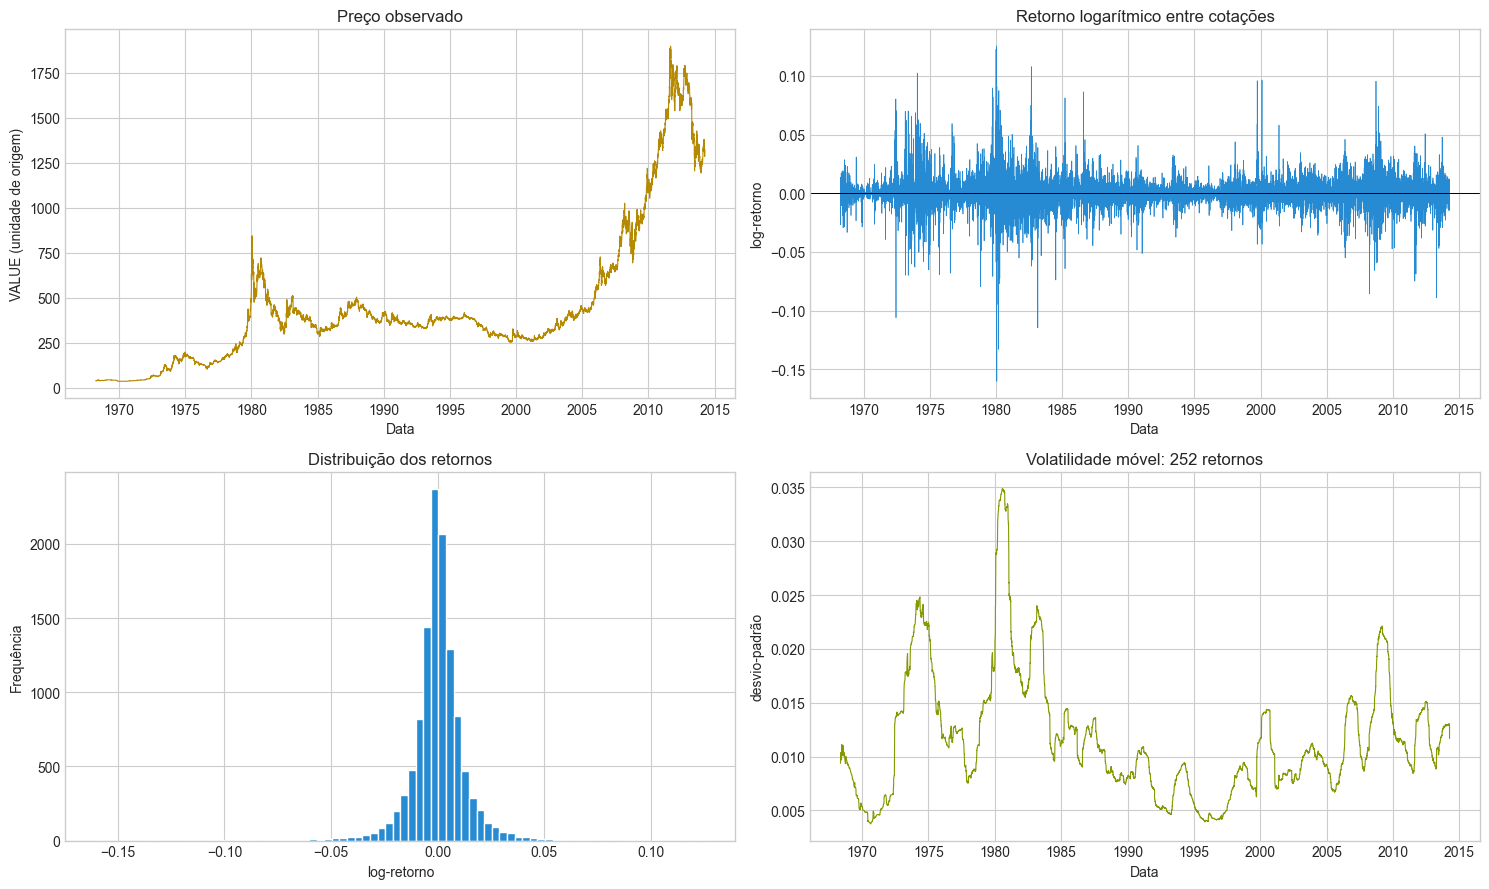

,count,mean,min,max,last
ano,,,,,
2005,252,444.987897,411.50,537.50,513.00
2006,252,604.337897,520.75,725.75,635.70
2007,253,696.431225,608.30,841.75,836.50
2008,254,872.372244,692.50,1023.50,865.00
2009,253,973.658103,813.00,1218.25,1104.00
2010,253,1226.664625,1052.25,1426.00,1410.25
2011,251,1573.159960,1316.00,1896.50,1574.50
2012,252,1668.857143,1537.50,1790.00,1664.00
2013,253,1409.505929,1192.75,1692.50,1201.50


,log_return_1d
count,11640.000000
mean,0.000305
std,0.012943
min,-0.160286
1%,-0.037167
5%,-0.018102
50%,0.000000
95%,0.019198
99%,0.037283
max,0.125345


In [4]:
eda = df_clean[['DATE', 'VALUE']].copy()
eda['log_return_1d'] = np.log(eda.VALUE).diff()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes[0, 0].plot(eda.DATE, eda.VALUE, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço observado', xlabel='Data', ylabel='VALUE (unidade de origem)')
axes[0, 1].plot(eda.DATE, eda.log_return_1d, lw=.5, color='#268bd2')
axes[0, 1].axhline(0, color='black', lw=.7)
axes[0, 1].set(title='Retorno logarítmico entre cotações', xlabel='Data', ylabel='log-retorno')
axes[1, 0].hist(eda.log_return_1d.dropna(), bins=80, color='#268bd2', edgecolor='white')
axes[1, 0].set(title='Distribuição dos retornos', xlabel='log-retorno', ylabel='Frequência')
axes[1, 1].plot(eda.DATE, eda.log_return_1d.rolling(252, min_periods=30).std(),
                lw=.8, color='#859900')
axes[1, 1].set(title='Volatilidade móvel: 252 retornos', xlabel='Data', ylabel='desvio-padrão')
plt.tight_layout(); plt.show()

annual_summary = eda.set_index('DATE').VALUE.resample('YE').agg(['count', 'mean', 'min', 'max', 'last'])
annual_summary.index = annual_summary.index.year
annual_summary.index.name = 'ano'
display(annual_summary.tail(10))
display(eda.log_return_1d.describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())


## 4. Tabela de modelagem exploratória

Cada origem `t` usa o preço observado até `t`. As janelas móveis usam `shift(1)`; os alvos são derivados do próximo preço **observado**, que pode estar depois da próxima linha do CSV. `TARGET_UP` da fonte e `IS_HOLIDAY` ficam fora de `X`. A direção derivada é apenas diagnóstica, não um alvo aprovado para os quatro modelos.


In [5]:
prepared = df_clean[['DATE', 'VALUE', 'gap_days']].rename(columns={'VALUE': 'price_t'}).copy()
prepared['log_price_t'] = np.log(prepared.price_t)
prepared['log_return_t'] = prepared.log_price_t.diff()

for lag in (1, 2, 5, 10, 21):
    prepared[f'price_lag_{lag}'] = prepared.price_t.shift(lag)
    prepared[f'return_lag_{lag}'] = prepared.log_return_t.shift(lag)
for window in (5, 10, 21):
    prepared[f'price_ma_{window}'] = prepared.price_t.shift(1).rolling(window).mean()
    prepared[f'return_vol_{window}'] = prepared.log_return_t.shift(1).rolling(window).std()

prepared['day_of_week'] = prepared.DATE.dt.dayofweek
prepared['month'] = prepared.DATE.dt.month
prepared['month_sin'] = np.sin(2 * np.pi * prepared.month / 12)
prepared['month_cos'] = np.cos(2 * np.pi * prepared.month / 12)
prepared['target_date'] = prepared.DATE.shift(-1)
prepared['target_gap_days'] = (prepared.target_date - prepared.DATE).dt.days
prepared['target_price_t_plus_1'] = prepared.price_t.shift(-1)
prepared['target_log_return_t_plus_1'] = np.log(prepared.target_price_t_plus_1) - prepared.log_price_t
prepared['target_up_next_observed'] = prepared.target_price_t_plus_1.gt(prepared.price_t).astype('Int64')
prepared.loc[prepared.target_price_t_plus_1.isna(), 'target_up_next_observed'] = pd.NA

target_columns = ['target_price_t_plus_1', 'target_log_return_t_plus_1', 'target_up_next_observed']
excluded = ['DATE', 'target_date', 'target_gap_days', *target_columns]
feature_columns = [c for c in prepared.columns if c not in excluded]
assert 'TARGET_UP' not in feature_columns and 'IS_HOLIDAY' not in feature_columns
model_df = prepared.dropna(subset=feature_columns + target_columns).reset_index(drop=True)
print(f'Linhas modeláveis: {len(model_df):,} | features: {len(feature_columns)}')
print(f'Maior horizonte entre cotações: {model_df.target_gap_days.max():.0f} dias')
display(model_df.head())


Linhas modeláveis: 11,618 | features: 24
Maior horizonte entre cotações: 6 dias


,DATE,price_t,gap_days,log_price_t,log_return_t,price_lag_1,return_lag_1,price_lag_2,return_lag_2,price_lag_5,return_lag_5,price_lag_10,return_lag_10,price_lag_21,return_lag_21,price_ma_5,return_vol_5,price_ma_10,return_vol_10,price_ma_21,return_vol_21,day_of_week,month,month_sin,month_cos,target_date,target_gap_days,target_price_t_plus_1,target_log_return_t_plus_1,target_up_next_observed
0,1968-05-03,39.6,1.0,3.678829,0.008878,39.25,0.003829,39.10,0.000000,38.50,0.006515,37.65,0.001329,37.6,-0.010582,38.90,0.005618,38.510,0.007312,37.995238,0.010160,4,5,0.5,-0.866025,1968-05-06,3.0,39.7,0.002522,1
1,1968-05-06,39.7,3.0,3.681351,0.002522,39.60,0.008878,39.25,0.003829,38.55,0.001298,38.30,0.017117,37.7,0.002656,39.12,0.005855,38.705,0.007361,38.090476,0.009883,0,5,0.5,-0.866025,1968-05-07,1.0,39.3,-0.010127,0
2,1968-05-07,39.3,1.0,3.671225,-0.010127,39.70,0.002522,39.60,0.008878,39.10,0.014166,38.05,-0.006549,36.7,-0.026883,39.35,0.005650,38.845,0.006029,38.185714,0.009883,1,5,0.5,-0.866025,1968-05-08,1.0,39.5,0.005076,1
3,1968-05-08,39.5,1.0,3.676301,0.005076,39.30,-0.010127,39.70,0.002522,39.10,0.000000,38.35,0.007853,37.2,0.013532,39.39,0.007021,38.970,0.006759,38.309524,0.007866,2,5,0.5,-0.866025,1968-05-09,1.0,39.7,0.005051,1
4,1968-05-09,39.7,1.0,3.681351,0.005051,39.50,0.005076,39.30,-0.010127,39.25,0.003829,38.25,-0.002611,37.0,-0.005391,39.47,0.007201,39.085,0.006604,38.419048,0.007522,3,5,0.5,-0.866025,1968-05-10,1.0,39.8,0.002516,1


## 5. Corte cronológico exploratório

O corte 80%/20% reproduz a exploração anterior, após formar as linhas modeláveis. Ele não define o teste final: o projeto ainda precisa estabelecer horizonte e origens comuns. Como o alvo de uma origem usa a próxima cotação observada, excluímos do treino qualquer linha cujo `target_date` alcance o início do teste.


,conjunto,linhas,origem_inicial,origem_final,alvo_final
0,treino,9293,1968-05-03,2005-01-27,2005-01-28
1,teste,2324,2005-01-31,2014-04-09,2014-04-10


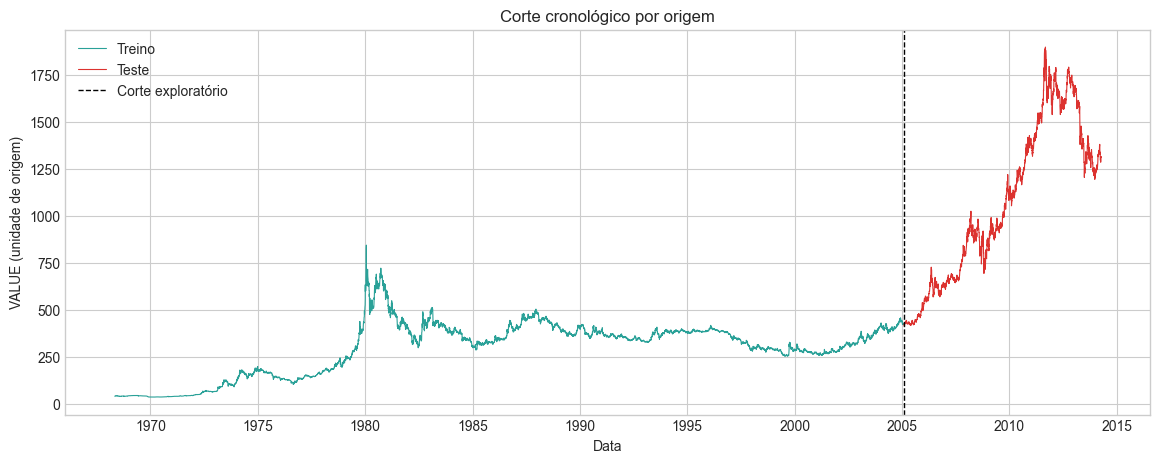

In [6]:
split_index = int(len(model_df) * TRAIN_RATIO)
test_df = model_df.iloc[split_index:].copy()
test_start = test_df.DATE.min()
train_df = model_df.iloc[:split_index].loc[lambda x: x.target_date < test_start].copy()
assert train_df.target_date.max() < test_start
assert train_df.DATE.max() < test_start
split_metadata = pd.DataFrame({
    'conjunto': ['treino', 'teste'],
    'linhas': [len(train_df), len(test_df)],
    'origem_inicial': [train_df.DATE.min(), test_df.DATE.min()],
    'origem_final': [train_df.DATE.max(), test_df.DATE.max()],
    'alvo_final': [train_df.target_date.max(), test_df.target_date.max()],
})
display(split_metadata)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df.DATE, train_df.price_t, label='Treino', lw=.8, color='#2aa198')
ax.plot(test_df.DATE, test_df.price_t, label='Teste', lw=.8, color='#dc322f')
ax.axvline(test_start, color='black', ls='--', lw=1, label='Corte exploratório')
ax.set(title='Corte cronológico por origem', xlabel='Data', ylabel='VALUE (unidade de origem)')
ax.legend(); plt.show()


## 6. Objetos para a próxima etapa

As matrizes não recebem escala ou imputação global. Transformações e seleção de features devem ser ajustadas somente no passado de cada origem. A previsão final dos quatro modelos deve usar o protocolo comum de `config/projeto.yaml` quando preenchido. O rótulo `TARGET_UP` fornecido não é usado como feature nem substitui os alvos derivados.


In [7]:
TARGET = 'target_log_return_t_plus_1'  # escolha exploratória, ainda pendente no projeto
X_train, y_train = train_df[feature_columns].copy(), train_df[TARGET].copy()
X_test, y_test = test_df[feature_columns].copy(), test_df[TARGET].copy()

baseline_return_test = pd.Series(0.0, index=y_test.index, name='return_zero')
baseline_price_test = test_df.price_t.rename('persistence_price')
print(f'Alvo exploratório: {TARGET}')
print(f'X_train: {X_train.shape}; y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}; y_test: {y_test.shape}')
display(X_train.head())


Alvo exploratório: target_log_return_t_plus_1
X_train: (9293, 24); y_train: (9293,)
X_test: (2324, 24); y_test: (2324,)


,price_t,gap_days,log_price_t,log_return_t,price_lag_1,return_lag_1,price_lag_2,return_lag_2,price_lag_5,return_lag_5,price_lag_10,return_lag_10,price_lag_21,return_lag_21,price_ma_5,return_vol_5,price_ma_10,return_vol_10,price_ma_21,return_vol_21,day_of_week,month,month_sin,month_cos
0,39.6,1.0,3.678829,0.008878,39.25,0.003829,39.10,0.000000,38.50,0.006515,37.65,0.001329,37.6,-0.010582,38.90,0.005618,38.510,0.007312,37.995238,0.010160,4,5,0.5,-0.866025
1,39.7,3.0,3.681351,0.002522,39.60,0.008878,39.25,0.003829,38.55,0.001298,38.30,0.017117,37.7,0.002656,39.12,0.005855,38.705,0.007361,38.090476,0.009883,0,5,0.5,-0.866025
2,39.3,1.0,3.671225,-0.010127,39.70,0.002522,39.60,0.008878,39.10,0.014166,38.05,-0.006549,36.7,-0.026883,39.35,0.005650,38.845,0.006029,38.185714,0.009883,1,5,0.5,-0.866025
3,39.5,1.0,3.676301,0.005076,39.30,-0.010127,39.70,0.002522,39.10,0.000000,38.35,0.007853,37.2,0.013532,39.39,0.007021,38.970,0.006759,38.309524,0.007866,2,5,0.5,-0.866025
4,39.7,1.0,3.681351,0.005051,39.50,0.005076,39.30,-0.010127,39.25,0.003829,38.25,-0.002611,37.0,-0.005391,39.47,0.007201,39.085,0.006604,38.419048,0.007522,3,5,0.5,-0.866025
